# Data Polutan di Kabupaten Bangkalan
# Business Understanding
## 1.  Tujuan Mengetahui Kualitas Udara di Daerah Masing-Masing

  - Pemantauan Kondisi Lingkungan: Mendapatkan gambaran akurat terkait tingkat polusi udara.
  - Identifikasi Tren dan Pola: Mengetahui waktu dan lokasi terjadinya lonjakan polusi.
  - Peringatan Dini (Early Warning System): Memberikan peringatan kepada masyarakat saat kualitas udara berbahaya.
  - Evaluasi Kebijakan: Mengukur efektivitas kebijakan lingkungan yang sudah berjalan.

## 2.  Manfaat

  - Bagi Masyarakat: Perlindungan kesehatan dari risiko penyakit pernapasan dan peningkatan kualitas hidup.
  - Bagi Pemerintah: Menjadi dasar pembuatan regulasi (Data-Driven Policy) dan membantu pencapaian Sustainable Development Goals (SDGs).
  - Bagi Bisnis & Industri: Membantu kepatuhan standar lingkungan (ESG) dan membuka peluang inovasi (seperti air purifier dll).
  - Bagi Akademisi & Peneliti: Menyediakan dataset yang valid untuk keperluan riset lanjutan terkait iklim dan kesehatan.

# Data Understanding
Tahap prapemrosesan ini memanfaatkan platform OpenEO untuk memproses data satelit Sentinel-5P Level-2 secara cloud-based, mengurangi beban komputasi lokal dengan melakukan agregasi spasial dan temporal langsung di server.

## Deskripsi Fitur
- **CO (Karbon Monoksida):** Gas beracun yang tidak berwarna dan tidak berbau. Dihasilkan dari pembakaran yang tidak sempurna, seperti dari asap kendaraan bermotor dan kegiatan industri.
- **NO2 (Nitrogen Dioksida):** Gas berwarna coklat kemerahan dengan bau yang menyengat. Utamanya bersumber dari emisi kendaraan, pembangkit listrik, dan pembakaran bahan bakar fosil. Terpapar NO2 tingkat tinggi dapat merusak saluran pernapasan.
- **SO2 (Sulfur Dioksida):** Gas tidak berwarna berbau tajam (seperti belerang terbakar). Mayoritas berasal dari pembakaran batu bara atau minyak bumi yang mengandung belerang. SO2 berperan dalam pembentukan hujan asam.

Pengecekan anomali (data aneh) dan *missing values* akan dieksplorasi lebih lanjut menggunakan *library* Pandas pada langkah akhir.

## 1. Persiapan Lingkungan dan Autentikasi
Langkah pertama adalah menginstal pustaka yang dibutuhkan dan melakukan autentikasi ke server Copernicus Data Space Ecosystem (CDSE) menggunakan OpenID Connect (OIDC).

In [ ]:
!pip install openeo

  Using cached openeo-0.51.0-py3-none-any.whl.metadata (8.9 kB)
  Using cached xarray-2025.1.1-py3-none-any.whl.metadata (11 kB)
  Using cached pystac-1.15.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached oschmod-0.3.12-py2.py3-none-any.whl.metadata (10.0 kB)
  Using cached geopandas-1.1.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pyogrio-0.13.0-cp311-abi3-win_amd64.whl.metadata (6.0 kB)
  Using cached pystac_core-1.15.2-py3-none-any.whl.metadata (1.3 kB)
  Using cached pystac_ext_classification-2.0.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached pystac_ext_datacube-2.2.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_eo-1.1.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached pystac_ext_file-2.1.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached pystac_ext_grid-1.1.1-py3-none-any.whl.metadata (1.9 kB)
  Using cached 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import openeo

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 2. Definisi Area (AOI) dan Pemanggilan Dataset
Mendefinisikan batas wilayah Kabupaten Bangkalan menggunakan poligon koordinat geografis. Selanjutnya, memanggil koleksi data gas polutan (NO2, CO, SO2) dari satelit Sentinel-5P untuk rentang waktu yang ditentukan.

![peta](img/peta.png)

In [4]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              113.0246284,
              -7.2136689
            ],
            [
              113.0863945,
              -6.8899587
            ],
            [
              112.8615302,
              -6.8911747
            ],
            [
              112.6774098,
              -7.0530501
            ],
            [
              112.7008918,
              -7.160955
            ],
            [
              113.0246284,
              -7.2136689
            ]
          ]
    ]
}

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"],
)

s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CO"],
)

s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-25", "2026-08-25"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["SO2"],
)


## 3. Agregasi Spasio-Temporal dan Eksekusi Server
Data satelit resolusi tinggi direduksi (diagregasi) menjadi nilai rata-rata harian (temporal) dan nilai rata-rata per wilayah AOI (spasial). Proses ini kemudian dikirim sebagai batch job untuk dieksekusi di server dan diunduh sebagai file NetCDF (.nc).

In [ ]:
# agregasi berdasarkan hari untuk menghindari adanya beberapa data per hari
s5p_NO2_daily = s5NO2.aggregate_temporal_period(reducer="mean", period="day")
s5p_CO_daily = s5CO.aggregate_temporal_period(reducer="mean", period="day")
s5p_SO2_daily = s5SO2.aggregate_temporal_period(reducer="mean", period="day")

# agregasi untuk menghasilkan data deret waktu rata-rata
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(reducer="mean", geometries=aoi)
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [6]:
# Eksekusi batch job dan unduh hasil ke format NetCDF (.nc)
job = s5p_NO2_aoi.execute_batch(title="NO2 in Bangkalan terbaru", outputfile="NO2Bangkalan Terbaru.nc")

0:00:00 Job 'j-260830154659407d8a2ba0143aa47407': send 'start'
0:00:03 Job 'j-260830154659407d8a2ba0143aa47407': queued (progress 0%)
0:00:08 Job 'j-260830154659407d8a2ba0143aa47407': queued (progress 0%)
0:00:15 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:00:23 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:00:33 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:00:46 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:01:02 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:01:21 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:01:45 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:02:16 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:02:53 Job 'j-260830154659407d8a2ba0143aa47407': running (progress N/A)
0:03:40 Job 'j-260830154659407d8a2ba0143aa47407': finished (progress 100%)


In [7]:
job = s5p_CO_aoi.execute_batch(title="CO in Bangkalan terbaru", outputfile="COBangkalan Terbaru.nc")

0:00:00 Job 'j-26083015505141dea21acb4116b4bfcd': send 'start'
0:00:02 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:00:07 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:00:14 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:00:22 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:00:32 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:00:45 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:01:00 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:01:20 Job 'j-26083015505141dea21acb4116b4bfcd': queued (progress 0%)
0:01:44 Job 'j-26083015505141dea21acb4116b4bfcd': running (progress N/A)
0:02:14 Job 'j-26083015505141dea21acb4116b4bfcd': running (progress N/A)
0:02:52 Job 'j-26083015505141dea21acb4116b4bfcd': running (progress N/A)
0:03:39 Job 'j-26083015505141dea21acb4116b4bfcd': finished (progress 100%)


In [8]:
job = s5p_SO2_aoi.execute_batch(title="SO2 in Bangkalan terbaru", outputfile="SO2Bangkalan Terbaru.nc")

0:00:00 Job 'j-260830155440480b8a2532bea2ffac43': send 'start'
0:00:03 Job 'j-260830155440480b8a2532bea2ffac43': queued (progress 0%)
0:00:08 Job 'j-260830155440480b8a2532bea2ffac43': queued (progress 0%)
0:00:14 Job 'j-260830155440480b8a2532bea2ffac43': queued (progress 0%)
0:00:23 Job 'j-260830155440480b8a2532bea2ffac43': queued (progress 0%)
0:00:33 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:00:45 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:01:01 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:01:20 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:01:45 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:02:15 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:02:52 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:03:39 Job 'j-260830155440480b8a2532bea2ffac43': running (progress N/A)
0:04:38 Job 'j-260830155440480b8a2532bea2ffac43': finished (progress 

## 4. Transformasi Data (NetCDF ke CSV)
Membaca file multi-dimensi NetCDF hasil unduhan, mengekstrak nilai polutan beserta atribut waktunya, melakukan penyesuaian format tanggal (YYYY-MM-DD), dan merestrukturisasinya menjadi format DataFrame menggunakan Pandas untuk disimpan sebagai CSV.

In [ ]:
!pip install netCDF4

  Using cached netcdf4-1.7.4-cp311-abi3-win_amd64.whl.metadata (2.1 kB)
Using cached netcdf4-1.7.4-cp311-abi3-win_amd64.whl (21.3 MB)

   -------------------- ------------------- 1/2 [netCDF4]
   -------------------- ------------------- 1/2 [netCDF4]
   -------------------- ------------------- 1/2 [netCDF4]
   ---------------------------------------- 2/2 [netCDF4]




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [10]:
import netCDF4
import numpy as np
import pandas as pd

def safe_date_list(time_values, units=None):
    try:
        if units:
            dates = netCDF4.num2date(time_values, units=units)
        else:
            dates = time_values
    except Exception:
        dates = time_values

    out = []
    for value in dates:
        if hasattr(value, "strftime"):
            out.append(value.strftime("%Y-%m-%d"))
        elif isinstance(value, np.datetime64):
            out.append(pd.to_datetime(str(value)).strftime("%Y-%m-%d"))
        else:
            try:
                out.append(pd.to_datetime(value).strftime("%Y-%m-%d"))
            except Exception:
                out.append(str(value))
    return out

dsNO2 = netCDF4.Dataset("NO2Bangkalan Terbaru.nc")
dsCO = netCDF4.Dataset("COBangkalan Terbaru.nc")
dsSO2 = netCDF4.Dataset("SO2Bangkalan Terbaru.nc")

In [11]:
values = np.asarray(dsNO2.variables["NO2"][:])
if values.ndim > 1:
    values = values.squeeze()

timeNO2 = dsNO2.variables["t"][:]
unitsNO2 = getattr(dsNO2.variables["t"], "units", None)
dates = safe_date_list(timeNO2, unitsNO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "NO2": values
})

df.to_csv("NO2_Bangkalan_timeseries_terbaru.csv", index=False)

In [12]:
values = np.asarray(dsCO.variables["CO"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeCO = dsCO.variables["t"][:]
unitsCO = getattr(dsCO.variables["t"], "units", None)
dates = safe_date_list(timeCO, unitsCO)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "CO": values
})

df.to_csv("CO_Bangkalan_timeseries_terbaru.csv", index=False)

In [13]:
values = np.asarray(dsSO2.variables["SO2"][:])
if values.ndim > 2:
    values = values.mean(axis=(1, 2))
elif values.ndim == 2:
    values = values.squeeze()
    if values.ndim > 1:
        values = values.mean(axis=0)
else:
    values = values.reshape(-1)

timeSO2 = dsSO2.variables["t"][:]
unitsSO2 = getattr(dsSO2.variables["t"], "units", None)
dates = safe_date_list(timeSO2, unitsSO2)

if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

# Buat dataframe dan simpan ke CSV
if len(dates) != len(values):
    n = min(len(dates), len(values))
    dates = dates[:n]
    values = values[:n]

df = pd.DataFrame({
    "date": dates,
    "SO2": values
})

df.to_csv("SO2_Bangkalan_timeseries_terbaru.csv", index=False)

## 5. Eksplorasi Data (Pencarian Data Aneh / Outlier)
Langkah ini bertujuan untuk memastikan kelengkapan data hasil ekstraksi. Kita akan memuat kembali ketiga file CSV yang telah disimpan ke dalam satu *dataframe* terpadu, mengecek adanya *missing values* (data yang kosong), dan mendeskripsikan secara statistik untuk melihat adanya anomali (data yang nilainya tidak wajar/sangat ekstrim).

In [14]:
import pandas as pd

# Memuat ulang data dari file CSV yang sudah dibuat
df_no2 = pd.read_csv("NO2_Bangkalan_timeseries_terbaru.csv")
df_co = pd.read_csv("CO_Bangkalan_timeseries_terbaru.csv")
df_so2 = pd.read_csv("SO2_Bangkalan_timeseries_terbaru.csv")

# Menggabungkan data berdasarkan kolom 'date'
df_combined = df_no2.merge(df_co, on='date', how='outer').merge(df_so2, on='date', how='outer')

for col in ['NO2', 'CO', 'SO2']:
    df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

# Konversi kolom 'date' ke tipe datetime Pandas untuk konsistensi
df_combined['date'] = pd.to_datetime(df_combined['date'])

print("========== Pengecekan Missing Values ==========")
print(df_combined.isnull().sum())
print("\n========== Pengecekan Data Aneh (Deskripsi Statistik) ==========")
print(df_combined.describe())

========== Pengecekan Missing Values ==========
date     0
NO2     33
CO      40
SO2      9
dtype: int64

========== Pengecekan Data Aneh (Deskripsi Statistik) ==========
                                date           NO2          CO         SO2
count                            310  2.770000e+02  270.000000  301.000000
mean   2026-03-04 13:05:01.935483904  2.417944e-05    0.028614    0.000033
min              2025-08-25 00:00:00 -6.819737e-07    0.020487   -0.000821
25%              2025-12-02 06:00:00  1.744446e-05    0.026734   -0.000025
50%              2026-03-15 12:00:00  2.301858e-05    0.028324    0.000032
75%              2026-06-06 18:00:00  3.019271e-05    0.030207    0.000087
max              2026-08-24 00:00:00  7.737131e-05    0.044761    0.000592
std                              NaN  1.003848e-05    0.002931    0.000130


## 6. Visualisasi Grafik Time Series
Sesuai kebutuhan tugas, data polutan (NO2, CO, SO2) dari rentang waktu Januari 2025 hingga akhir Agustus 2026 akan divisualisasikan dalam bentuk grafik deret waktu (*time series*). Ini memudahkan kita dalam melihat tren dan fluktuasi konsentrasi polutan udara di Kabupaten Bangkalan.

In [ ]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


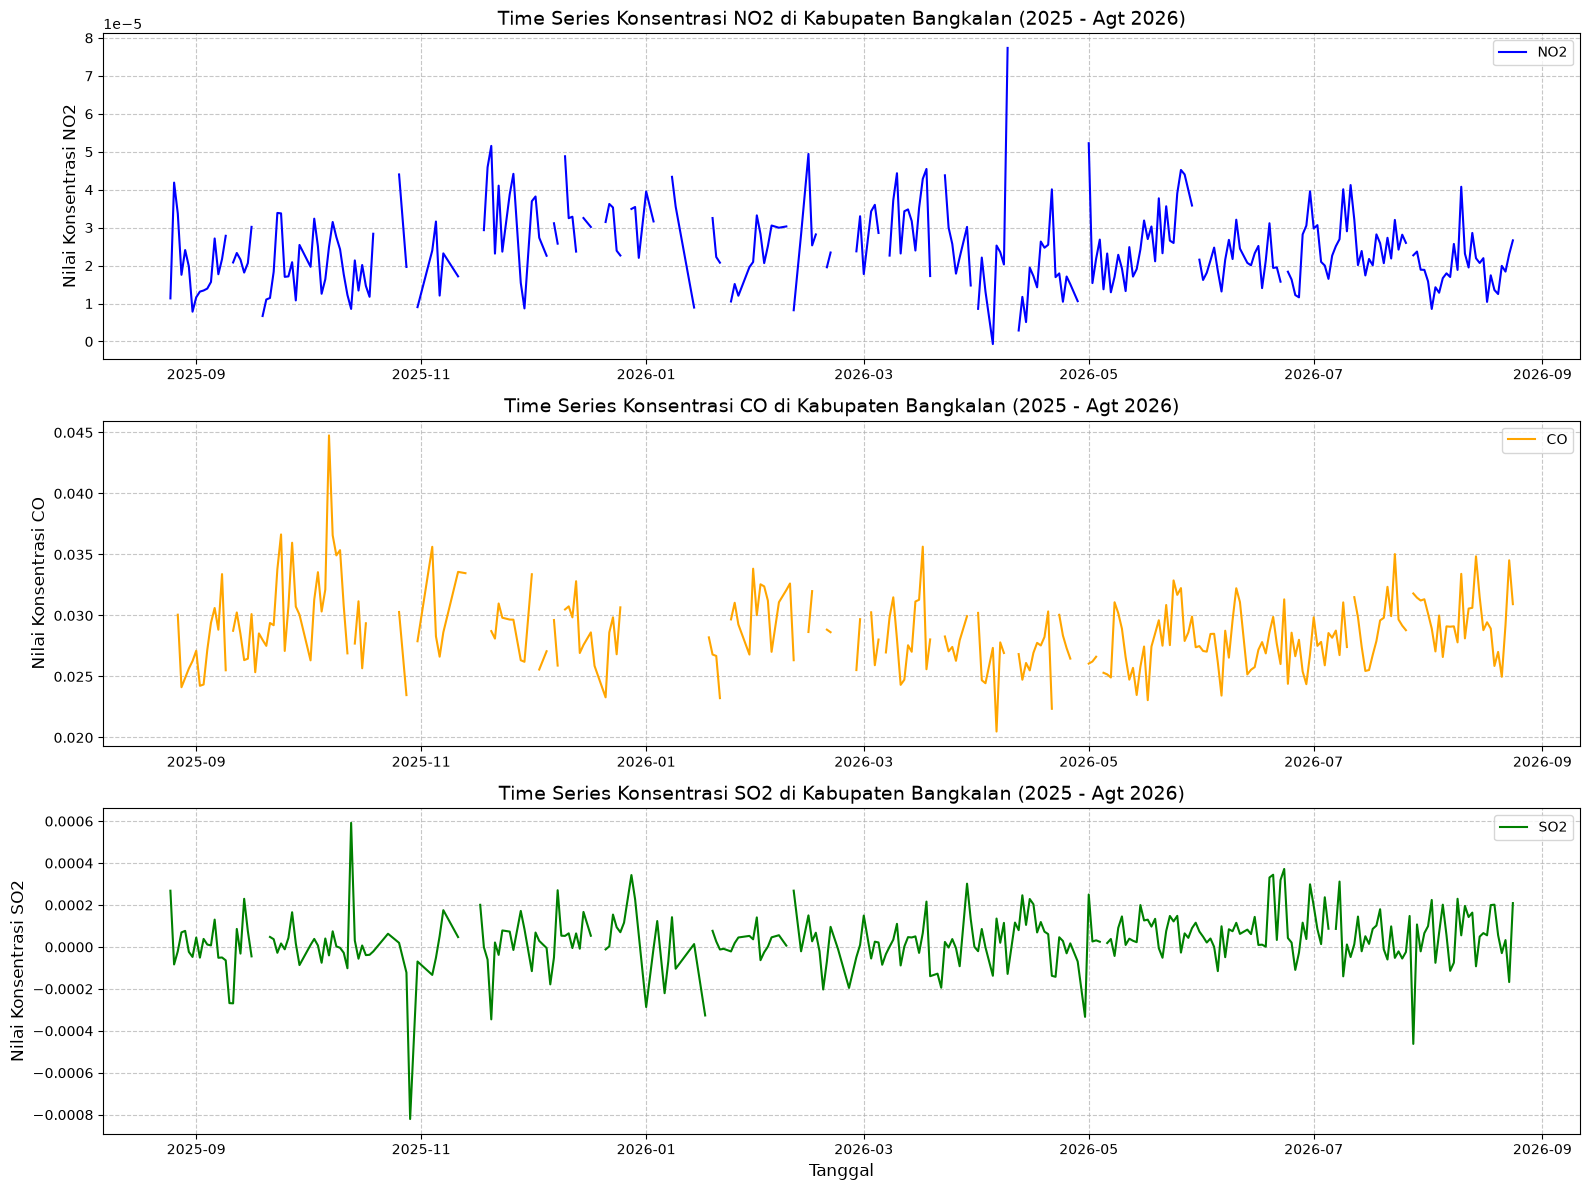

In [ ]:
import matplotlib.pyplot as plt

# diurutkan berdasarkan tanggal sebelum plotting
df_combined = df_combined.sort_values(by='date')

# Konfigurasi ukuran figure utama
plt.figure(figsize=(16, 12))

# Grafik NO2
plt.subplot(3, 1, 1)
plt.plot(df_combined['date'], df_combined['NO2'], color='blue', label='NO2', linewidth=1.5)
plt.title('Time Series Konsentrasi NO2 di Kabupaten Bangkalan (2025 - Agt 2026)', fontsize=14)
plt.ylabel('Nilai Konsentrasi NO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Grafik CO
plt.subplot(3, 1, 2)
plt.plot(df_combined['date'], df_combined['CO'], color='orange', label='CO', linewidth=1.5)
plt.title('Time Series Konsentrasi CO di Kabupaten Bangkalan (2025 - Agt 2026)', fontsize=14)
plt.ylabel('Nilai Konsentrasi CO', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Grafik SO2 
plt.subplot(3, 1, 3)
plt.plot(df_combined['date'], df_combined['SO2'], color='green', label='SO2', linewidth=1.5)
plt.title('Time Series Konsentrasi SO2 di Kabupaten Bangkalan (2025 - Agt 2026)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai Konsentrasi SO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Merapikan jarak antar subplot dan menampilkan grafik
plt.tight_layout()
plt.show()

## Interpretasi Grafik Time Series

Grafik time series menunjukkan pola fluktuasi konsentrasi ketiga polutan utama di Kabupaten Bangkalan selama periode pengamatan dari 25 Agustus 2025 hingga 25 Agustus 2026. Secara umum, masing-masing polutan memiliki karakteristik temporal yang berbeda, tetapi semuanya menunjukkan adanya periode peningkatan konsentrasi yang perlu diperhatikan.

- Grafik NO2 menunjukkan variasi yang cukup jelas dengan rata-rata sekitar 2,42 × 10^-5 dan puncak tertinggi terjadi pada 9 April 2026. Peningkatan ini mencerminkan kemungkinan adanya lonjakan emisi akibat aktivitas transportasi, industri, atau kondisi atmosfer yang memperkuat akumulasi NO2 di wilayah tersebut. Setelah puncak, konsentrasi cenderung menurun, meskipun masih berada di level yang cukup berfluktuasi.
- Grafik CO memiliki pola yang relatif lebih stabil dibandingkan NO2 dan SO2, dengan nilai rata-rata sekitar 0,0286 dan puncak tertinggi pada 7 Oktober 2025 (0,0448). Kondisi ini menunjukkan adanya periode lonjakan emisi karbon monoksida yang cukup signifikan, kemungkinan berkaitan dengan aktivitas kendaraan dan pembakaran tidak sempurna pada musim tertentu.
- Grafik SO2 menunjukkan dinamika yang paling beragam, dengan puncak tertinggi pada 13 Oktober 2025 dan adanya beberapa nilai ekstrem maupun negatif yang kemungkinan mencerminkan variasi pengukuran atau noise dari proses retrieval satelit. Meskipun demikian, secara umum SO2 tetap menunjukkan adanya periode naik-turun yang relevan untuk dikaji lebih lanjut dalam kaitannya dengan sumber emisi dan kondisi atmosfer.

Secara keseluruhan, data ini menunjukkan bahwa Kabupaten Bangkalan tidak sepenuhnya bersifat stabil dalam hal kualitas udara. Terdapat beberapa periode puncak konsentrasi yang dapat menjadi indikator peningkatan paparan polutan terhadap kesehatan masyarakat. Oleh karena itu, grafik time series ini sangat penting untuk melihat tren, momen kritis, serta kebutuhan pemantauan yang lebih intensif di masa depan.


# Kesimpulan

Berdasarkan analisis data kualitas udara Kabupaten Bangkalan dari produk Sentinel-5P untuk periode 25 Agustus 2025 hingga 24 Agustus 2026, dapat disimpulkan bahwa:

- Data NO2, CO, dan SO2 berhasil diproses dan diubah dari format NetCDF menjadi time series yang siap dianalisis, dengan tidak ditemukan missing values yang signifikan pada data akhir.
- Proses agregasi spasial-temporal menggunakan rata-rata harian dan rata-rata wilayah AOI menghasilkan representasi konsentrasi udara yang cukup konsisten untuk membandingkan pola antar polutan.
- NO2 menunjukkan fluktuasi yang cukup jelas dengan puncak tertinggi pada 9 April 2026, sedangkan CO dan SO2 mengalami lonjakan yang cukup menonjol pada Oktober 2025. Kondisi ini menunjukkan bahwa ada periode tertentu di mana emisi udara meningkat dan perlu mendapat perhatian lebih.
- CO memiliki nilai rata-rata sekitar 0,0286 dengan puncak 0,0448, sementara NO2 memiliki rata-rata sekitar 2,42 × 10^-5 dengan puncak 7,74 × 10^-5, dan SO2 mencapai puncak 5,92 × 10^-4 pada 13 Oktober 2025. Hal ini menunjukkan bahwa ketiga polutan memiliki tingkat variasi dan momen kritis yang berbeda, tetapi semuanya berkontribusi terhadap kualitas udara dan berpotensi memengaruhi kesehatan masyarakat.
- Secara umum, hasil analisis menunjukkan bahwa Kabupaten Bangkalan mengalami fluktuasi konsentrasi polutan yang beragam sepanjang waktu, dengan beberapa puncak yang dapat menjadi indikator meningkatnya aktivitas emisi atau perubahan kondisi atmosfer dan lingkungan.

Dengan demikian, pemanfaatan data satelit Sentinel-5P terbukti efektif untuk memantau kualitas udara secara luas dan berkelanjutan, serta dapat menjadi dasar yang kuat untuk peringatan dini, evaluasi kebijakan lingkungan, dan langkah mitigasi pencemaran udara di Kabupaten Bangkalan.